In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from typing import List
from dataclasses import dataclass
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression
import scipy.stats as stats
import pandas as pd

In [ ]:
def set_seed(seed: int):
    np.random.seed(seed)

def safe_normalize_rows(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

def get_epsilon(d, T):
    return ((d * np.log(max(T, 2))) ** 2 / T) ** (1/3)

def get_alpha(T, B_noise):
    return 1 / (T + 2 * (T**2) * (3 + (B_noise + 1) * (T**(1/3))))

def get_mu(d, epsilon, B_theta, B_y, B_x, T, alpha):
    sqrt_tmp = np.sqrt(d * np.log((1 + T * (B_x ** 2)) / alpha))
    return epsilon / (B_theta + B_y * sqrt_tmp)

def norm_invA(x, A):
    return np.sqrt(np.dot(x, np.linalg.solve(A, x)))


In [ ]:
#Code to make sure that you have the data correctly setup
#Download dynamic pricing data from:"https://www.kaggle.com/datasets/arashnic/dynamic-pricing-dataset?resource=download"
#Unzip the file and put the dynamic_pricing.csv under Ride_Sharing_Data folder
# project/
#  ├── script.ipynb
#  └── Ride_Sharing_Data/
#       └── dynamic_pricing.csv
df = pd.read_csv("Ride_Sharing_Data/dynamic_pricing.csv")

df['Demand_Supply_Ratio'] = df['Number_of_Riders'] / (df['Number_of_Drivers'] + 1e-6)

print(df.head())      # first 5 rows
print(df.columns)     # column names
print(df.info())      # summary

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Historical_Cost_of_Ride', axis=1).astype(float).values
y = df_encoded['Historical_Cost_of_Ride'].astype(float).values

y = y / y.max()
price_grid = np.linspace(0.0, 1.0, 100)

# Normalize features (important for bandits)
X = safe_normalize_rows(X)

T, d = X.shape

   Number_of_Riders  Number_of_Drivers Location_Category  \
0                90                 45             Urban   
1                58                 39          Suburban   
2                42                 31             Rural   
3                89                 28             Rural   
4                78                 22             Rural   

  Customer_Loyalty_Status  Number_of_Past_Rides  Average_Ratings  \
0                  Silver                    13             4.47   
1                  Silver                    72             4.06   
2                  Silver                     0             3.99   
3                 Regular                    67             4.31   
4                 Regular                    74             3.77   

  Time_of_Booking Vehicle_Type  Expected_Ride_Duration  \
0           Night      Premium                      90   
1         Evening      Economy                      43   
2       Afternoon      Premium                      76  

In [ ]:
@dataclass
class EnvConfig:
    name: str
    d: int
    T: int
    n_contexts: int = 50
    bound_x: float = 1.0
    bound_theta: float = 1.0
    bound_noise: float = 1.0
    noise_scale: float = 0.3
    drift_scale: float = 0.25
    cold_start_fraction: float = 0.1
    semantic_topics: int = 5

#Used for real data from kaggle
class RealDataEnv:
    def __init__(self, X, y, noise_scale=0.1, seed=0):
        self.X = X
        self.y = y
        self.T = len(y)
        self.rng = np.random.default_rng(seed)
        self.noise_scale = noise_scale

    def sample_context(self, t):
        return self.X[t]

    def step(self, price, t):
        x = self.X[t]
        true_value = self.y[t]

        # optional noise (to mimic uncertainty)
        noise = self.rng.normal(0, self.noise_scale)
        y_noisy = true_value + noise

        prob = 1 / (1 + np.exp((price - y_noisy)/0.05))
        accept = int(self.rng.random() < prob)
        reward = price * accept

        return {
            "x": x,
            "y": y_noisy,
            "accept": accept,
            "reward": reward
        }

    def oracle_price(self, t, price_grid):
        true_value = self.y[t]

        probs = 1 / (1 + np.exp((price_grid - true_value)/0.05))
        revenues = price_grid * probs

        best_idx = np.argmax(revenues)
        return price_grid[best_idx], revenues[best_idx]

In [ ]:
class BasePricingAlgo:
    def __init__(self, name: str, d: int, B_x: float, B_theta: float, B_noise: float):
        self.name = name
        self.d = d
        self.B_x = B_x
        self.B_theta = B_theta
        self.B_noise = B_noise
        self.B_y = 1.0

    def select_price(self, x: np.ndarray, t: int) -> float:
        raise NotImplementedError

    def update(self, x: np.ndarray, price: float, accept: int, t: int):
        raise NotImplementedError

In [ ]:
class VAPEAlgo(BasePricingAlgo):
    def __init__(self, d, T, L_xi=1.0, B_x=1.0, B_theta=1.0, B_noise=1.0):
        super().__init__("VAPE", d, B_x, B_theta, B_noise)
        self.T = T
        self.L_xi = L_xi
        self.epsilon = 0.5 * get_epsilon(d, T)
        self.alpha = get_alpha(T, B_noise)
        self.mu = 0.5 * get_mu(d, self.epsilon, B_theta, self.B_y, B_x, T, self.alpha)

        self.theta_hat = np.zeros(d)
        self.V = np.eye(d)
        self.sum_ox = np.zeros(d)

        self.K = math.ceil((B_noise + 1) / self.epsilon)
        self.N = np.ones(2 * self.K + 1)
        self.D_hat = np.zeros(2 * self.K + 1)

    def update_theta_V(self, x, o):
        self.V = self.V + np.outer(x, x)
        self.sum_ox = self.sum_ox + (o - 0.5) * x
        self.theta_hat = 2 * self.B_y * np.linalg.solve(self.V, self.sum_ox)

    def precheck_actions(self, g_hat):
        arms = []
        for k in range(2 * self.K + 1):
            est = g_hat + (k - self.K) * self.epsilon
            if 0 < est < self.B_y:
                arms.append(k)
        if len(arms) == 0:
            arms = [self.K]
        return arms

    def compute_bounds(self, g_hat):
        ks = np.arange(-self.K, self.K + 1)
        est = g_hat + ks * self.epsilon
        width = np.sqrt(2 * np.log(1 / self.alpha) / self.N) + 2 * self.L_xi * self.epsilon
        ucb = est * np.clip(self.D_hat + width, 0.0, 1.0)
        lcb = est * np.clip(self.D_hat - width, 0.0, 1.0)
        return ucb, lcb

    def select_arm(self, ucb, lcb, prechecked):
        max_lcb = np.max(lcb[prechecked])
        valid = [k for k in prechecked if ucb[k] >= max_lcb]
        if len(valid) == 0:
            valid = prechecked
        return min(valid, key=lambda k: self.N[k])

    def select_price(self, x, t):
        norm = norm_invA(x, self.V)

        if norm > self.mu:
            return np.random.uniform(0.0, self.B_y)

        g_hat = float(np.dot(x, self.theta_hat))
        ucb, lcb = self.compute_bounds(g_hat)
        prechecked = self.precheck_actions(g_hat)
        k = self.select_arm(ucb, lcb, prechecked)
        price = g_hat + (k - self.K) * self.epsilon
        return float(np.clip(price, 0.0, self.B_y))

    def update(self, x, price, accept, t):
        norm = norm_invA(x, self.V)
        if norm > self.mu:
            self.update_theta_V(x, accept)
        else:
            g_hat = float(np.dot(x, self.theta_hat))
            k = np.argmin(np.abs((g_hat + (np.arange(-self.K, self.K+1)*self.epsilon)) - price))
            k = int(np.clip(k, 0, 2 * self.K))
            self.D_hat[k] = (self.N[k] * self.D_hat[k] + accept) / (self.N[k] + 1)
            self.N[k] += 1

In [ ]:
class CAPEAlgo(BasePricingAlgo):
    def __init__(self, d, T, B_x=1.0, B_theta=1.0, B_noise=1.0,
                 n_price_grid=81, bandwidth=None, prior_strength=1.0,
                 theta_prior_mean=None):
        super().__init__("CAPE", d, B_x, B_theta, B_noise)
        self.T = T
        self.price_grid = np.linspace(0.0, self.B_y, n_price_grid)
        self.bandwidth = 0.1
        self.prior_strength = prior_strength

        self.theta_hat = np.zeros(d) if theta_prior_mean is None else theta_prior_mean.copy()
        self.V = np.eye(d) * prior_strength
        self.b = self.V @ self.theta_hat

        self.history_x = []
        self.history_p = []
        self.history_o = []

    def update_theta(self, x, o):
        # same idea as VAPE-style linear update
        self.V = self.V + np.outer(x, x)
        self.b = self.b + 2 * self.B_y * (o - 0.5) * x
        self.theta_hat = np.linalg.solve(self.V, self.b)

    def kernel(self, z):
        out = np.zeros_like(z, dtype=float)
        mask = np.abs(z) <= 1
        out[mask] = 0.75 * (1 - z[mask] ** 2)
        return out

    def estimate_monotone_survival(self, x):
        if len(self.history_p) < 20:
            # bootstrap warm-start
            surv = np.clip(1 - self.price_grid / max(self.B_y, 1e-8), 0, 1)
            return surv

        g_hat = float(np.dot(x, self.theta_hat))
        increments = np.array(self.history_p) - np.array(self.history_x) @ self.theta_hat
        accepts = np.array(self.history_o)

        surv_est = []
        for inc in (self.price_grid - g_hat):
            z = (increments - inc) / self.bandwidth
            w = self.kernel(z)
            denom = np.sum(w) + 1e-8
            num = np.sum(w * accepts)
            surv_est.append(num / denom)

        surv_est = np.array(surv_est)

        # monotone decreasing projection
        ir = IsotonicRegression(increasing=False, out_of_bounds='clip')
        surv_iso = ir.fit_transform(self.price_grid, surv_est)
        surv_iso = np.clip(surv_iso, 1e-4, 1.0)
        return surv_iso

    def select_price(self, x, t):
        if t < max(25, self.d * 5):
            return np.random.uniform(0.0, self.B_y)

        surv = self.estimate_monotone_survival(x)

        # approximate posterior sampling on demand
        pseudo_counts = 30.0
        alpha = 1 + pseudo_counts * surv
        beta = 1 + pseudo_counts * (1 - surv)
        sampled_surv = np.random.beta(alpha, beta)

        sampled_rev = self.price_grid * sampled_surv
        return float(self.price_grid[np.argmax(sampled_rev)])

    def update(self, x, price, accept, t):
        self.update_theta(x, accept)
        self.history_x.append(x.copy())
        self.history_p.append(float(price))
        self.history_o.append(int(accept))

In [ ]:
class ExploreThenUCBAlgo(BasePricingAlgo):
    def __init__(self, d, T, B_x=1.0, B_theta=1.0, B_noise=1.0,
                 explore_frac=0.2, n_price_grid=61, theta_prior_mean=None):
        super().__init__("ExUCB", d, B_x, B_theta, B_noise)
        self.T = T
        self.explore_T = max(int(explore_frac * T), 50)
        self.price_grid = np.linspace(0.0, self.B_y, n_price_grid)

        self.X = []
        self.P = []
        self.O = []

        self.theta_hat = np.zeros(d) if theta_prior_mean is None else theta_prior_mean.copy()
        self.lr = LinearRegression(fit_intercept=False)

    def fit_theta(self):
        if len(self.X) < self.d:
            return
        X = np.array(self.X)
        O = np.array(self.O)
        target = self.B_y * O
        self.lr.fit(X, target)
        self.theta_hat = self.lr.coef_

    def estimate_acceptance_curve(self, x):
        if len(self.P) < 20:
            return np.clip(1 - self.price_grid / max(self.B_y, 1e-8), 0, 1)

        g_hat = float(np.dot(x, self.theta_hat))
        increments = np.array(self.P) - np.array(self.X) @ self.theta_hat
        accepts = np.array(self.O)

        band = max(0.08, len(self.P) ** (-1/5))
        acc = []
        for inc in self.price_grid - g_hat:
            z = (increments - inc) / band
            w = np.exp(-0.5 * z ** 2)
            denom = np.sum(w) + 1e-8
            acc.append(np.sum(w * accepts) / denom)

        acc = np.array(acc)
        ir = IsotonicRegression(increasing=False, out_of_bounds='clip')
        acc = ir.fit_transform(self.price_grid, acc)
        return np.clip(acc, 1e-4, 1.0)

    def select_price(self, x, t):
        if t < self.explore_T:
            return np.random.uniform(0.0, self.B_y)

        self.fit_theta()
        acc = self.estimate_acceptance_curve(x)

        n_eff = max(len(self.P), 1)
        bonus = 0.5 * np.sqrt(2 * np.log(max(t + 2, 3)) / n_eff)
        ucb = self.price_grid * np.clip(acc + bonus, 0, 1)
        return float(self.price_grid[np.argmax(ucb)])

    def update(self, x, price, accept, t):
        self.X.append(x.copy())
        self.P.append(float(price))
        self.O.append(int(accept))

In [ ]:
def run_single(env_cfg: EnvConfig, algo_name: str, seed: int = 0):
    set_seed(seed)

    env = RealDataEnv(X, y, noise_scale=0.1, seed=seed)

    theta_prior = None

    if algo_name == "VAPE":
        algo = VAPEAlgo(
            d=env_cfg.d, T=env_cfg.T,
            L_xi=1.0,
            B_x=env_cfg.bound_x,
            B_theta=env_cfg.bound_theta,
            B_noise=env_cfg.bound_noise
        )
    elif algo_name == "CAPE":
        algo = CAPEAlgo(
            d=env_cfg.d, T=env_cfg.T,
            B_x=env_cfg.bound_x,
            B_theta=env_cfg.bound_theta,
            B_noise=env_cfg.bound_noise,
            theta_prior_mean=theta_prior
        )
    elif algo_name == "ExUCB":
        algo = ExploreThenUCBAlgo(
            d=env_cfg.d, T=env_cfg.T,
            B_x=env_cfg.bound_x,
            B_theta=env_cfg.bound_theta,
            B_noise=env_cfg.bound_noise,
            theta_prior_mean=theta_prior
        )
    else:
        raise ValueError(f"Unknown algo {algo_name}")

    rewards = np.zeros(env_cfg.T)
    oracle_rewards = np.zeros(env_cfg.T)
    prices = np.zeros(env_cfg.T)
    accepts = np.zeros(env_cfg.T)
    valuation_means = np.zeros(env_cfg.T)

    for t in range(env_cfg.T):
        x = env.sample_context(t)
        p = algo.select_price(x, t)

        step_out = env.step(p, t)

        accept = step_out["accept"]
        reward = step_out["reward"]

        _, oracle_reward = env.oracle_price(t, price_grid)

        algo.update(x, p, accept, t)

        rewards[t] = reward
        oracle_rewards[t] = oracle_reward
        prices[t] = p
        accepts[t] = accept
        valuation_means[t] = step_out["y"]



    regret = np.cumsum(oracle_rewards - rewards)

    return {
        "algo": algo_name,
        "env": env_cfg.name,
        "rewards": rewards,
        "oracle_rewards": oracle_rewards,
        "cum_regret": regret,
        "prices": prices,
        "accepts": accepts,
        "valuation_means": valuation_means,
    }

In [ ]:
def run_benchmark(env_cfgs: List[EnvConfig], algos=("VAPE", "CAPE", "ExUCB"), n_seeds=10):
    results = {}

    for env_cfg in env_cfgs:
        results[env_cfg.name] = {}
        print(f"\nEnvironment: {env_cfg.name}")

        for algo in algos:
            print(f"  Running {algo} ...")
            runs = []
            for seed in range(n_seeds):
                out = run_single(env_cfg, algo, seed=seed)
                runs.append(out)
            results[env_cfg.name][algo] = runs

    return results

In [ ]:
def summarize_runs(runs):
    regrets = np.array([r["cum_regret"] for r in runs])
    rewards = np.array([np.cumsum(r["rewards"]) for r in runs])
    accepts = np.array([r["accepts"] for r in runs])

    return {
        "regret_mean": regrets.mean(axis=0),
        "regret_std": regrets.std(axis=0),
        "reward_mean": rewards.mean(axis=0),
        "reward_std": rewards.std(axis=0),
        "accept_mean": accepts.mean(axis=0),
        "accept_std": accepts.std(axis=0),
    }

def moving_average(x, window=50):
    x = np.array(x)
    if window <= 1:
        return x
    return np.convolve(x, np.ones(window)/window, mode='same')

def plot_env_results(results, env_name):
    env_res = results[env_name]
    T = len(next(iter(env_res.values()))[0]["cum_regret"])
    xs = np.arange(1, T + 1)

    plt.figure(figsize=(7, 4))
    for algo, runs in env_res.items():
        s = summarize_runs(runs)
        smooth_regret = moving_average(s["regret_mean"], window=20)
        plt.plot(xs, smooth_regret, label=algo)
        plt.fill_between(xs,
                         s["regret_mean"] - s["regret_std"],
                         s["regret_mean"] + s["regret_std"],
                         alpha=0.2)
    plt.title(f"Cumulative Regret: {env_name}")
    plt.xlabel("t")
    plt.ylabel("Cumulative regret")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    for algo, runs in env_res.items():
        s = summarize_runs(runs)
        plt.plot(xs, s["reward_mean"], label=algo)
        plt.fill_between(xs,
                         s["reward_mean"] - s["reward_std"],
                         s["reward_mean"] + s["reward_std"],
                         alpha=0.2)
    plt.title(f"Cumulative Reward: {env_name}")
    plt.xlabel("t")
    plt.ylabel("Cumulative reward")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    for algo, runs in env_res.items():
        s = summarize_runs(runs)

        smooth_accept = moving_average(s["accept_mean"], window=50)

        plt.plot(xs, smooth_accept, label=algo)

    plt.title(f"Acceptance Rate (Smoothed): {env_name}")
    plt.xlabel("t")
    plt.ylabel("Acceptance Rate")
    plt.legend()
    plt.show()

In [ ]:
T, d = X.shape

env_cfgs = [
    EnvConfig(name="RealData", d=d, T=T)
]

In [ ]:
results = run_benchmark(env_cfgs, algos=("VAPE", "CAPE", "ExUCB"), n_seeds=10)


Environment: RealData
  Running VAPE ...
  Running CAPE ...
  Running ExUCB ...


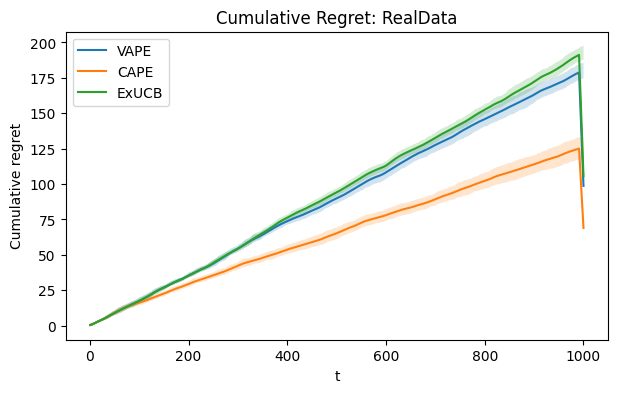

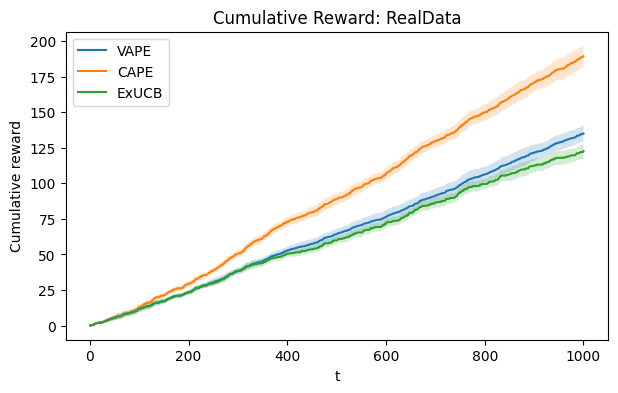

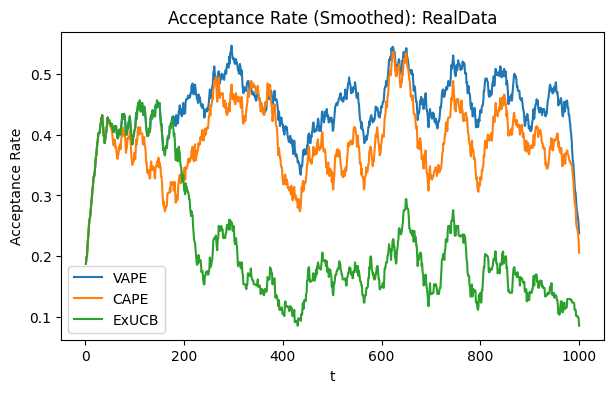

In [ ]:
for env_name in results:
    plot_env_results(results, env_name)


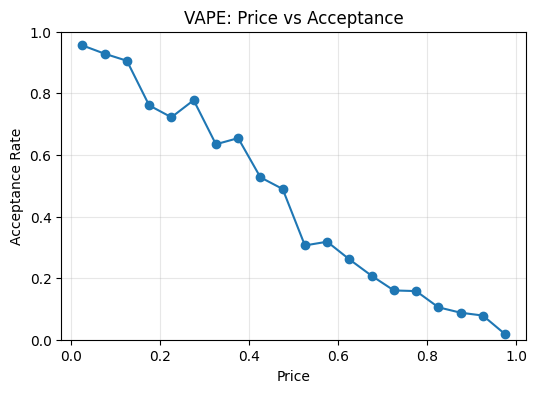

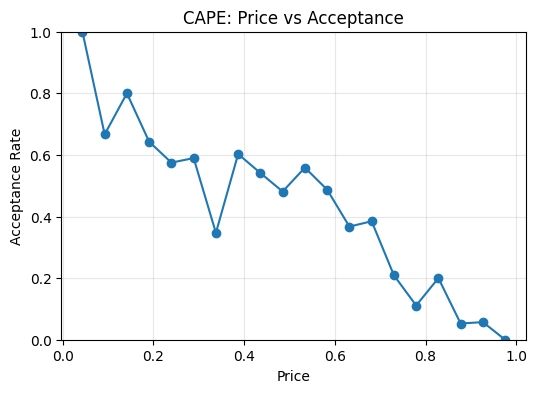

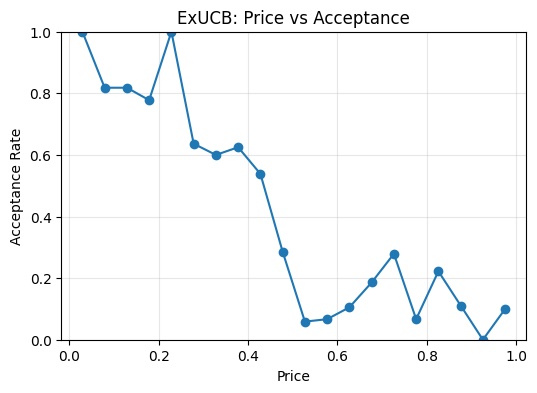

In [ ]:
def plot_price_acceptance(runs, title, bins=20):
    run = runs[0]

    prices = np.array(run["prices"])
    accepts = np.array(run["accepts"])

    bin_edges = np.linspace(prices.min(), prices.max(), bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    avg_accept = []

    for i in range(bins):
        mask = (prices >= bin_edges[i]) & (prices < bin_edges[i+1])
        if np.any(mask):
            avg_accept.append(accepts[mask].mean())
        else:
            avg_accept.append(np.nan)

    plt.figure(figsize=(6,4))
    plt.plot(bin_centers, avg_accept, marker='o')
    plt.ylim(0, 1)
    plt.xlabel("Price")
    plt.ylabel("Acceptance Rate")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

plot_price_acceptance(results["RealData"]["VAPE"], "VAPE: Price vs Acceptance")
plot_price_acceptance(results["RealData"]["CAPE"], "CAPE: Price vs Acceptance")
plot_price_acceptance(results["RealData"]["ExUCB"], "ExUCB: Price vs Acceptance")

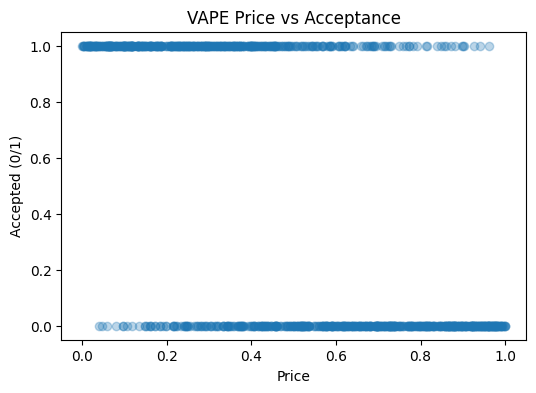

In [ ]:
runs = results["RealData"]["VAPE"]
run = runs[0]

prices = run["prices"]
accepts = run["accepts"]

plt.figure(figsize=(6,4))
plt.scatter(prices, accepts, alpha=0.3)
plt.xlabel("Price")
plt.ylabel("Accepted (0/1)")
plt.title("VAPE Price vs Acceptance")
plt.show()

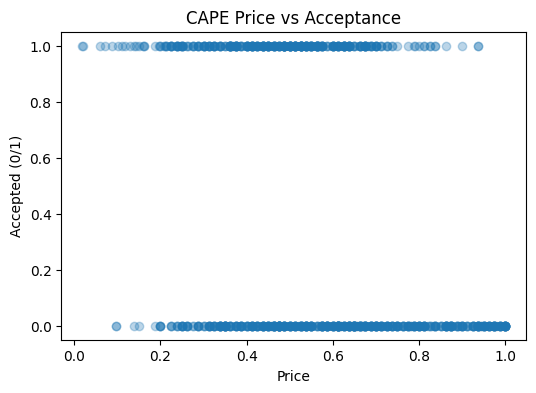

In [ ]:
runs = results["RealData"]["CAPE"]
run = runs[0]

prices = run["prices"]
accepts = run["accepts"]

plt.figure(figsize=(6,4))
plt.scatter(prices, accepts, alpha=0.3)
plt.xlabel("Price")
plt.ylabel("Accepted (0/1)")
plt.title("CAPE Price vs Acceptance")
plt.show()

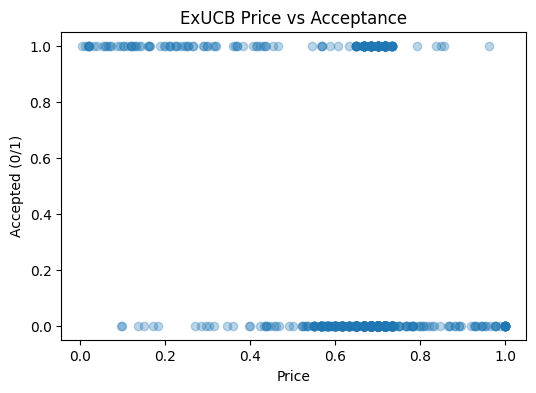

In [ ]:
runs = results["RealData"]["ExUCB"]
run = runs[0]

prices = run["prices"]
accepts = run["accepts"]

plt.figure(figsize=(6,4))
plt.scatter(prices, accepts, alpha=0.3)
plt.xlabel("Price")
plt.ylabel("Accepted (0/1)")
plt.title("ExUCB Price vs Acceptance")
plt.show()

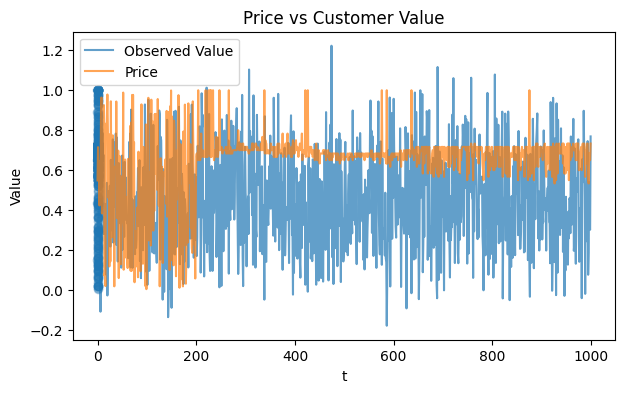

In [ ]:
values = run["valuation_means"]
prices = run["prices"]

plt.figure(figsize=(7,4))
plt.scatter(values, prices, alpha=0.3)
plt.plot(values, label="Observed Value", alpha=0.7)
plt.plot(prices, label="Price", alpha=0.7)
plt.legend()
plt.title("Price vs Customer Value")
plt.xlabel("t")
plt.ylabel("Value")
plt.show()

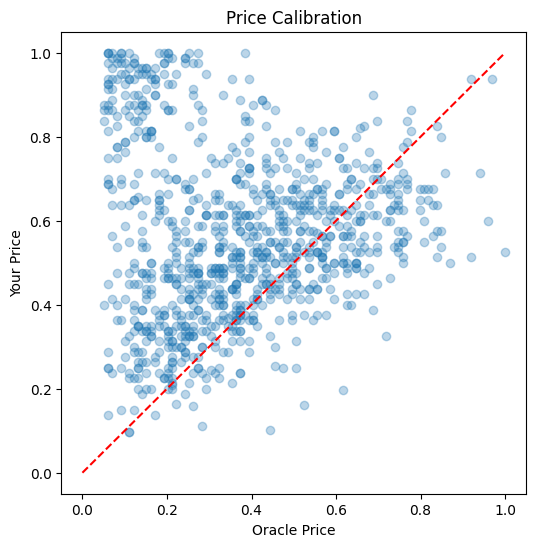

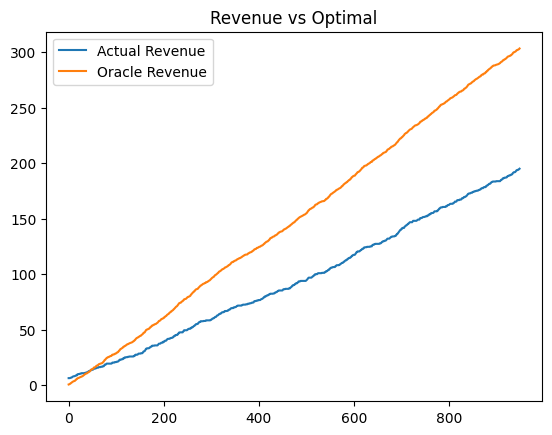

In [ ]:
def compute_oracle_price_per_timestep(true_value, price_grid, temp=0.05):
    probs = 1 / (1 + np.exp((price_grid - true_value) / temp))
    revenues = price_grid * probs
    best_idx = np.argmax(revenues)
    return price_grid[best_idx], revenues[best_idx]

price_grid = np.linspace(0.0, 1.0, 100)

run = results["RealData"]["CAPE"][0]

values = run["valuation_means"]
prices = run["prices"]

oracle_prices = []
oracle_rewards = []

for t in range(50, len(values)):
    y_t = values[t]
    p_star, r_star = compute_oracle_price_per_timestep(y_t, price_grid)
    oracle_prices.append(p_star)
    oracle_rewards.append(r_star)

plt.figure(figsize=(6,6))
plt.scatter(oracle_prices, prices[50:], alpha=0.3)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("Oracle Price")
plt.ylabel("Your Price")
plt.title("Price Calibration")
plt.show()

actual_rev = np.cumsum(run["rewards"])[50:]
oracle_rev = np.cumsum(oracle_rewards)

plt.plot(actual_rev, label="Actual Revenue")
plt.plot(oracle_rev, label="Oracle Revenue")
plt.legend()
plt.title("Revenue vs Optimal")
plt.show()

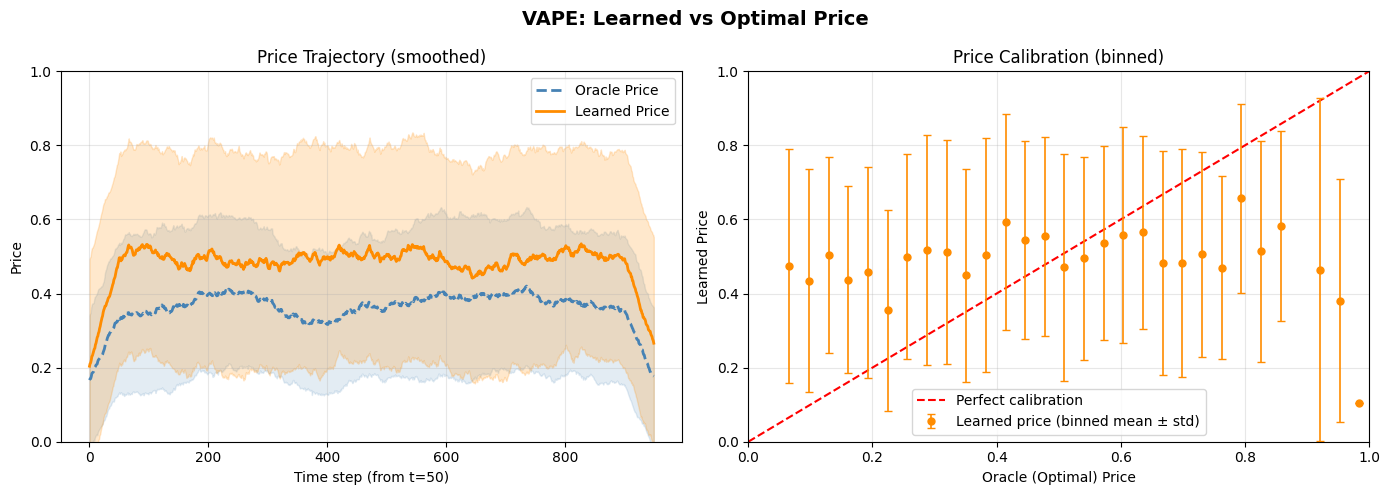

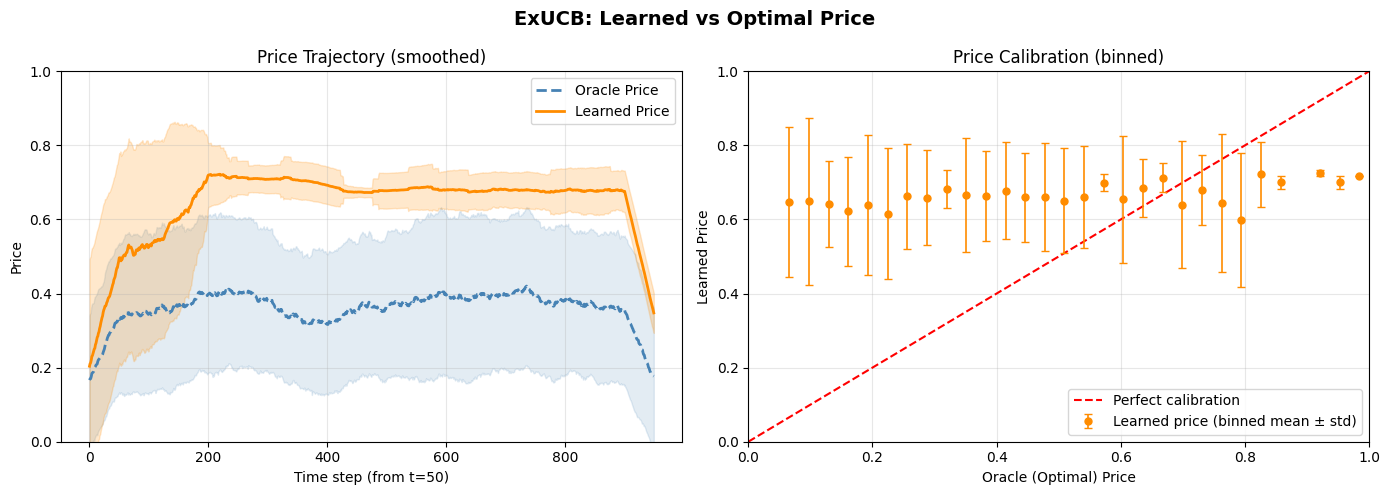

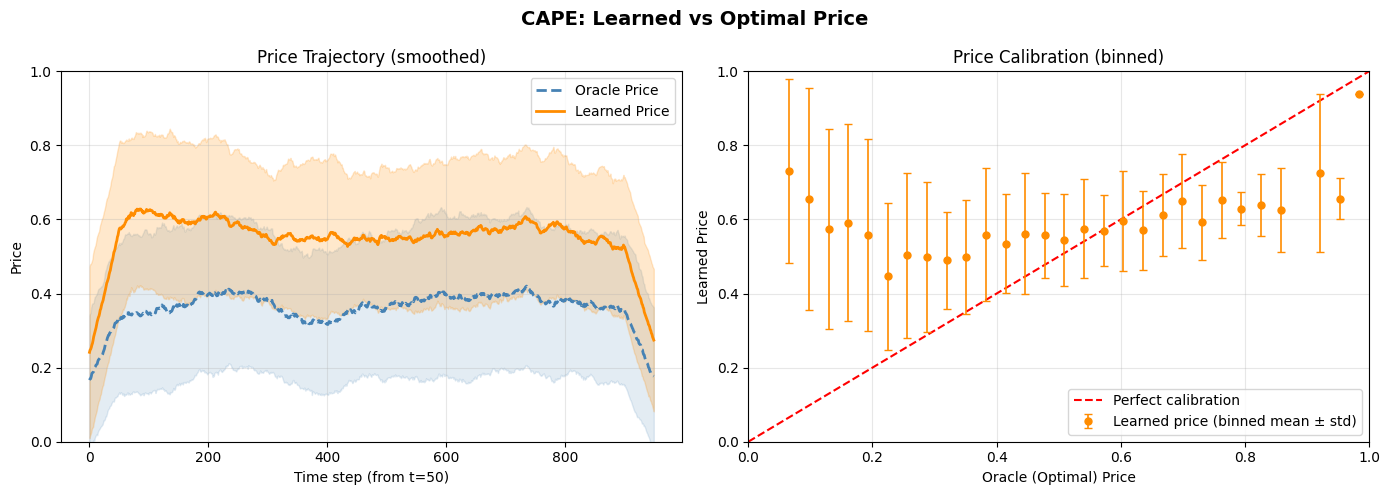

In [ ]:
def smooth(x, window=100):
    """Rolling mean with edge padding to preserve length."""
    x = np.array(x, dtype=float)
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode='same')

def rolling_std(x, window=100):
    x = np.array(x, dtype=float)
    half = window // 2
    out = np.full_like(x, np.nan)
    for i in range(len(x)):
        lo = max(0, i - half)
        hi = min(len(x), i + half + 1)
        out[i] = np.std(x[lo:hi])
    return out

def binned_calibration(oracle_prices, learned_prices, n_bins=30):
    """Bin oracle prices and compute mean + std of learned prices per bin."""
    edges = np.linspace(np.min(oracle_prices), np.max(oracle_prices), n_bins + 1)
    centers, means, stds = [], [], []
    for i in range(n_bins):
        mask = (oracle_prices >= edges[i]) & (oracle_prices < edges[i + 1])
        if np.any(mask):
            centers.append(0.5 * (edges[i] + edges[i + 1]))
            means.append(np.mean(learned_prices[mask]))
            stds.append(np.std(learned_prices[mask]))
    return np.array(centers), np.array(means), np.array(stds)

def plot_algo_performance(algo_name, run_data, price_grid, window=100):
    values = run_data["valuation_means"]
    prices = np.array(run_data["prices"], dtype=float)

    oracle_prices = []
    oracle_rewards = []
    for t in range(50, len(values)):
        p_star, r_star = compute_oracle_price_per_timestep(values[t], price_grid)
        oracle_prices.append(p_star)
        oracle_rewards.append(r_star)

    oracle_prices = np.array(oracle_prices)
    learned_prices = prices[50:]
    xs = np.arange(len(learned_prices))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{algo_name}: Learned vs Optimal Price", fontsize=14, fontweight="bold")

    #Left panel: smoothed price trajectories over time
    ax = axes[0]
    s_learned = smooth(learned_prices, window)
    s_oracle  = smooth(oracle_prices,  window)
    sd_learned = rolling_std(learned_prices, window)
    sd_oracle  = rolling_std(oracle_prices,  window)

    ax.plot(xs, s_oracle,  label="Oracle Price",  linestyle="--", color="steelblue",   linewidth=2)
    ax.fill_between(xs, s_oracle  - sd_oracle,  s_oracle  + sd_oracle,  alpha=0.15, color="steelblue")
    ax.plot(xs, s_learned, label="Learned Price", linestyle="-",  color="darkorange", linewidth=2)
    ax.fill_between(xs, s_learned - sd_learned, s_learned + sd_learned, alpha=0.2,  color="darkorange")

    ax.set_xlabel("Time step (from t=50)")
    ax.set_ylabel("Price")
    ax.set_title("Price Trajectory (smoothed)")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

    # Right panel: binned calibration scatter
    ax = axes[1]
    centers, means, stds = binned_calibration(oracle_prices, learned_prices, n_bins=30)

    ax.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect calibration")
    ax.errorbar(centers, means, yerr=stds, fmt="o", color="darkorange",
                ecolor="darkorange", elinewidth=1.2, capsize=3,
                markersize=5, label="Learned price (binned mean ± std)")

    ax.set_xlabel("Oracle (Optimal) Price")
    ax.set_ylabel("Learned Price")
    ax.set_title("Price Calibration (binned)")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

# Main execution loop
for algo in ["VAPE", "ExUCB", "CAPE"]:
    run = results["RealData"][algo][0]
    plot_algo_performance(algo, run, price_grid, window=100)


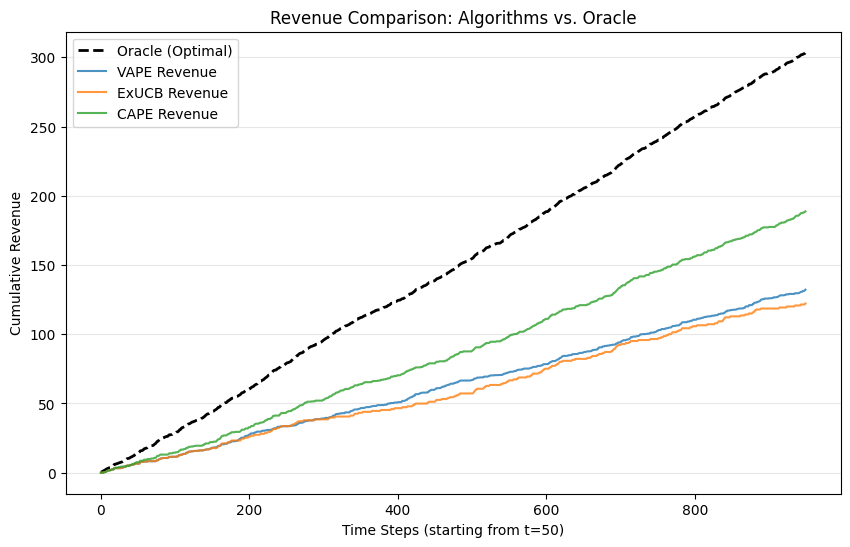

In [ ]:
plt.figure(figsize=(10, 6))

# 1. Compute Oracle Baseline (assuming it's similar across runs)
# We use the first algo's values to generate the Oracle line
first_algo = "VAPE"
values = results["RealData"][first_algo][0]["valuation_means"]
oracle_rev_list = []

for t in range(50, len(values)):
    _, r_star = compute_oracle_price_per_timestep(values[t], price_grid)
    oracle_rev_list.append(r_star)

oracle_total_rev = np.cumsum(oracle_rev_list)
plt.plot(oracle_total_rev, label="Oracle (Optimal)", color='black', linestyle='--', linewidth=2)

# 2. Plot each Algorithm's Revenue
algos = ["VAPE", "ExUCB", "CAPE"]
colors = ['tab:blue', 'tab:orange', 'tab:green']

for algo, color in zip(algos, colors):
    run = results["RealData"][algo][0]
    # Calculate cumulative revenue starting from index 50
    actual_rev = np.cumsum(run["rewards"][50:])

    plt.plot(actual_rev, label=f"{algo} Revenue", color=color, alpha=0.8)

plt.title("Revenue Comparison: Algorithms vs. Oracle")
plt.xlabel("Time Steps (starting from t=50)")
plt.ylabel("Cumulative Revenue")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()